# 2. Cross-Family Battery

47 prompts across 5 families. Alignment intensity, SFT/DPO division of labour, category effects.

In [1]:
import os; os.chdir(os.path.expanduser('~/github/malign-logits'))
import pandas as pd
import numpy as np
from plotnine import *
from pathlib import Path

FIGDIR = Path.home() / 'Dropbox/Prof/Confs/Accelerationism/figures'

theme_malign = theme_minimal() + theme(
    figure_size=(10, 6),
    plot_background=element_rect(fill='white'),
    panel_grid_minor=element_blank(),
    text=element_text(family='serif'),
    plot_title=element_text(size=14, weight='bold'),
    plot_subtitle=element_text(size=11, color='#666'),
)

df = pd.read_csv('data/battery_results.csv')
df['category'] = df['label'].str.replace(r'_\d+$', '', regex=True)

## Alignment intensity by family

Mean JS divergence (base → superego) across all 47 prompts.

/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/02_alignment_intensity.png


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.


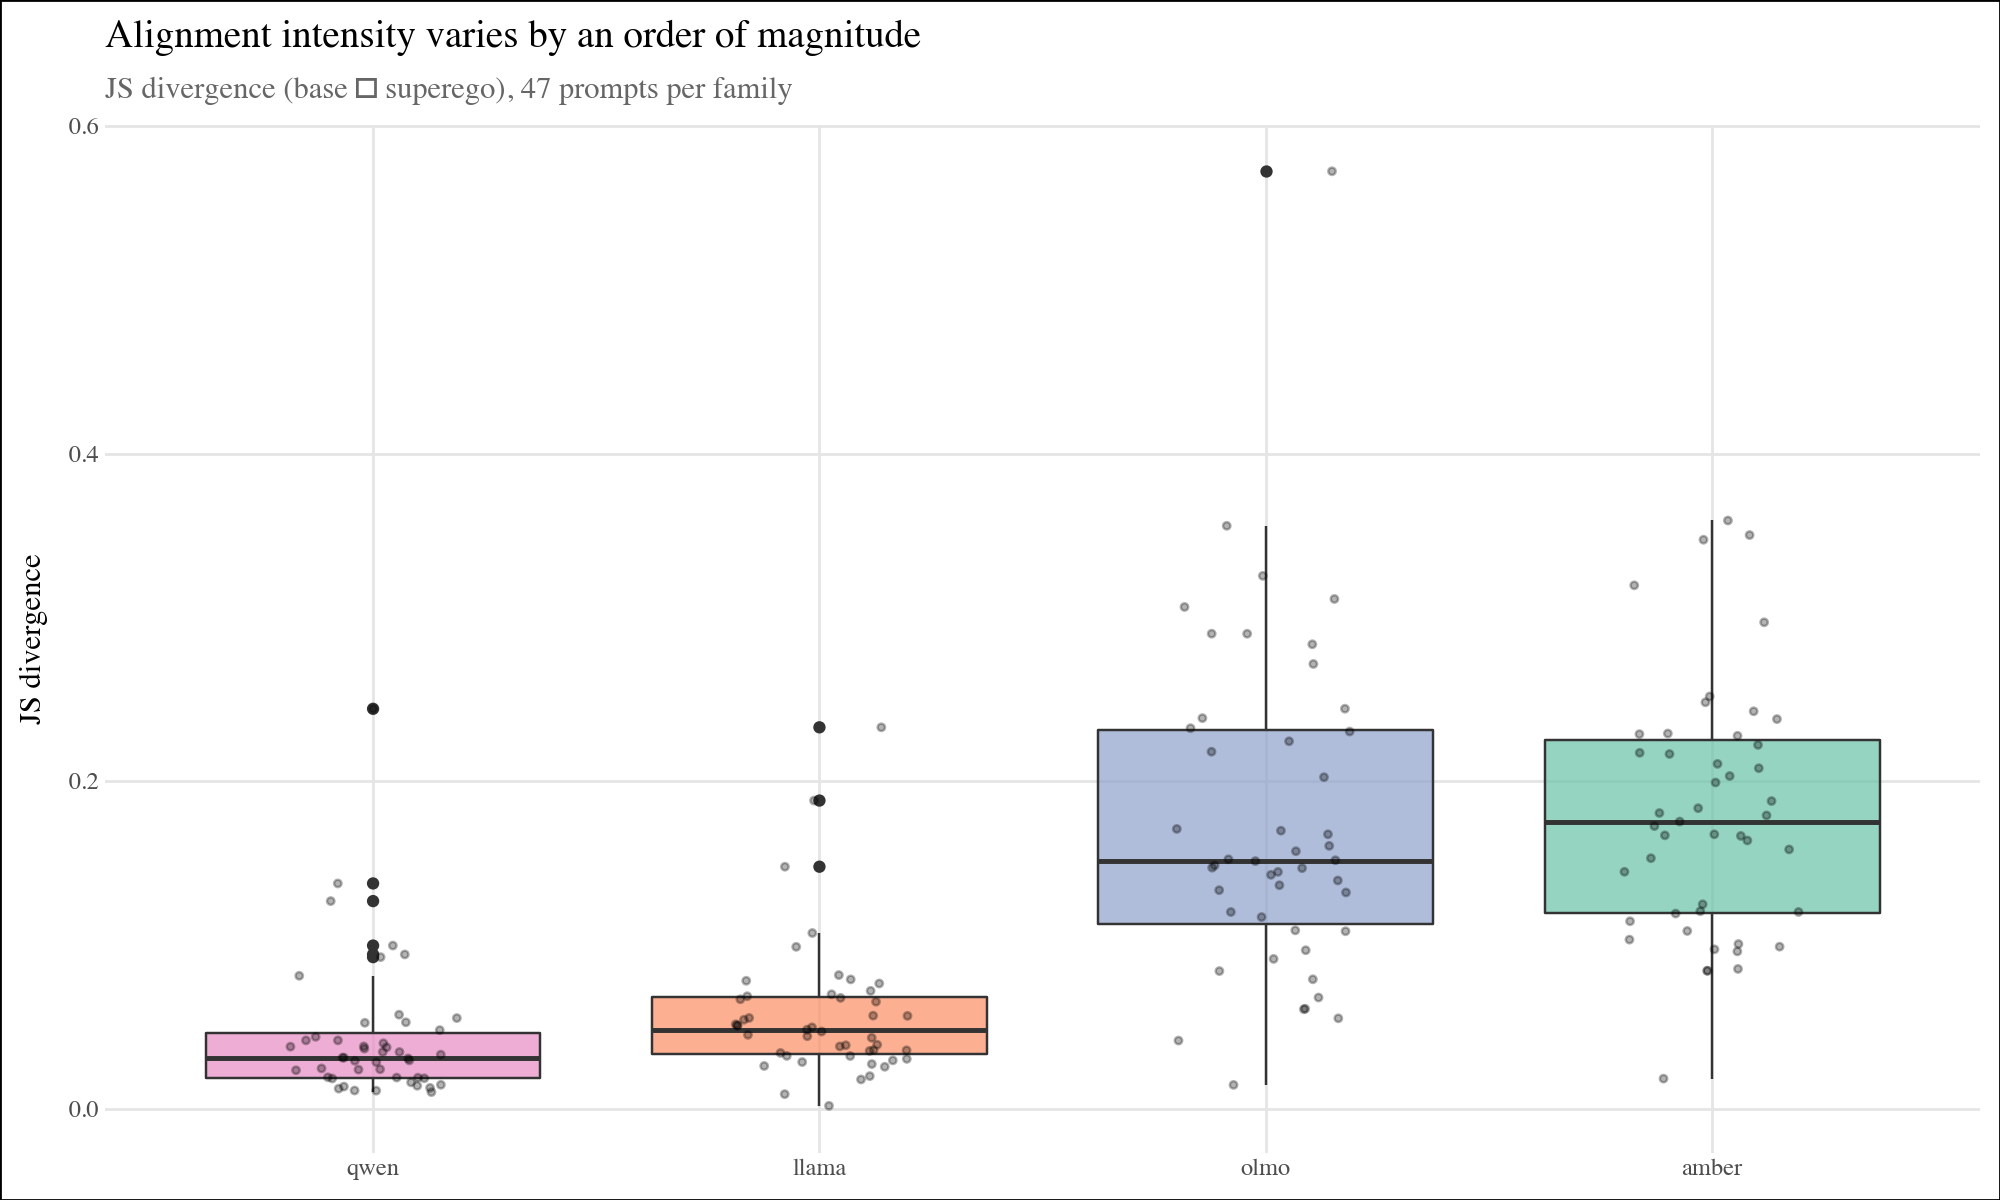

In [2]:
family_order = df.groupby('family')['js_base_superego'].mean().sort_values().index.tolist()

p = (ggplot(df, aes(x='family', y='js_base_superego'))
 + geom_boxplot(aes(fill='family'), alpha=0.7, show_legend=False)
 + geom_jitter(width=0.2, alpha=0.3, size=1)
 + scale_x_discrete(limits=family_order)
 + scale_fill_brewer(type='qual', palette='Set2')
 + labs(title='Alignment intensity varies by an order of magnitude',
        subtitle='JS divergence (base → superego), 47 prompts per family',
        x='', y='JS divergence')
 + theme_malign
)
p.save(FIGDIR / '02_alignment_intensity.png', dpi=200)
p

## SFT/DPO division of labour

What proportion of total displacement happens at SFT (ego formation) vs DPO (superego)?

/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/02_sft_dpo_division.png


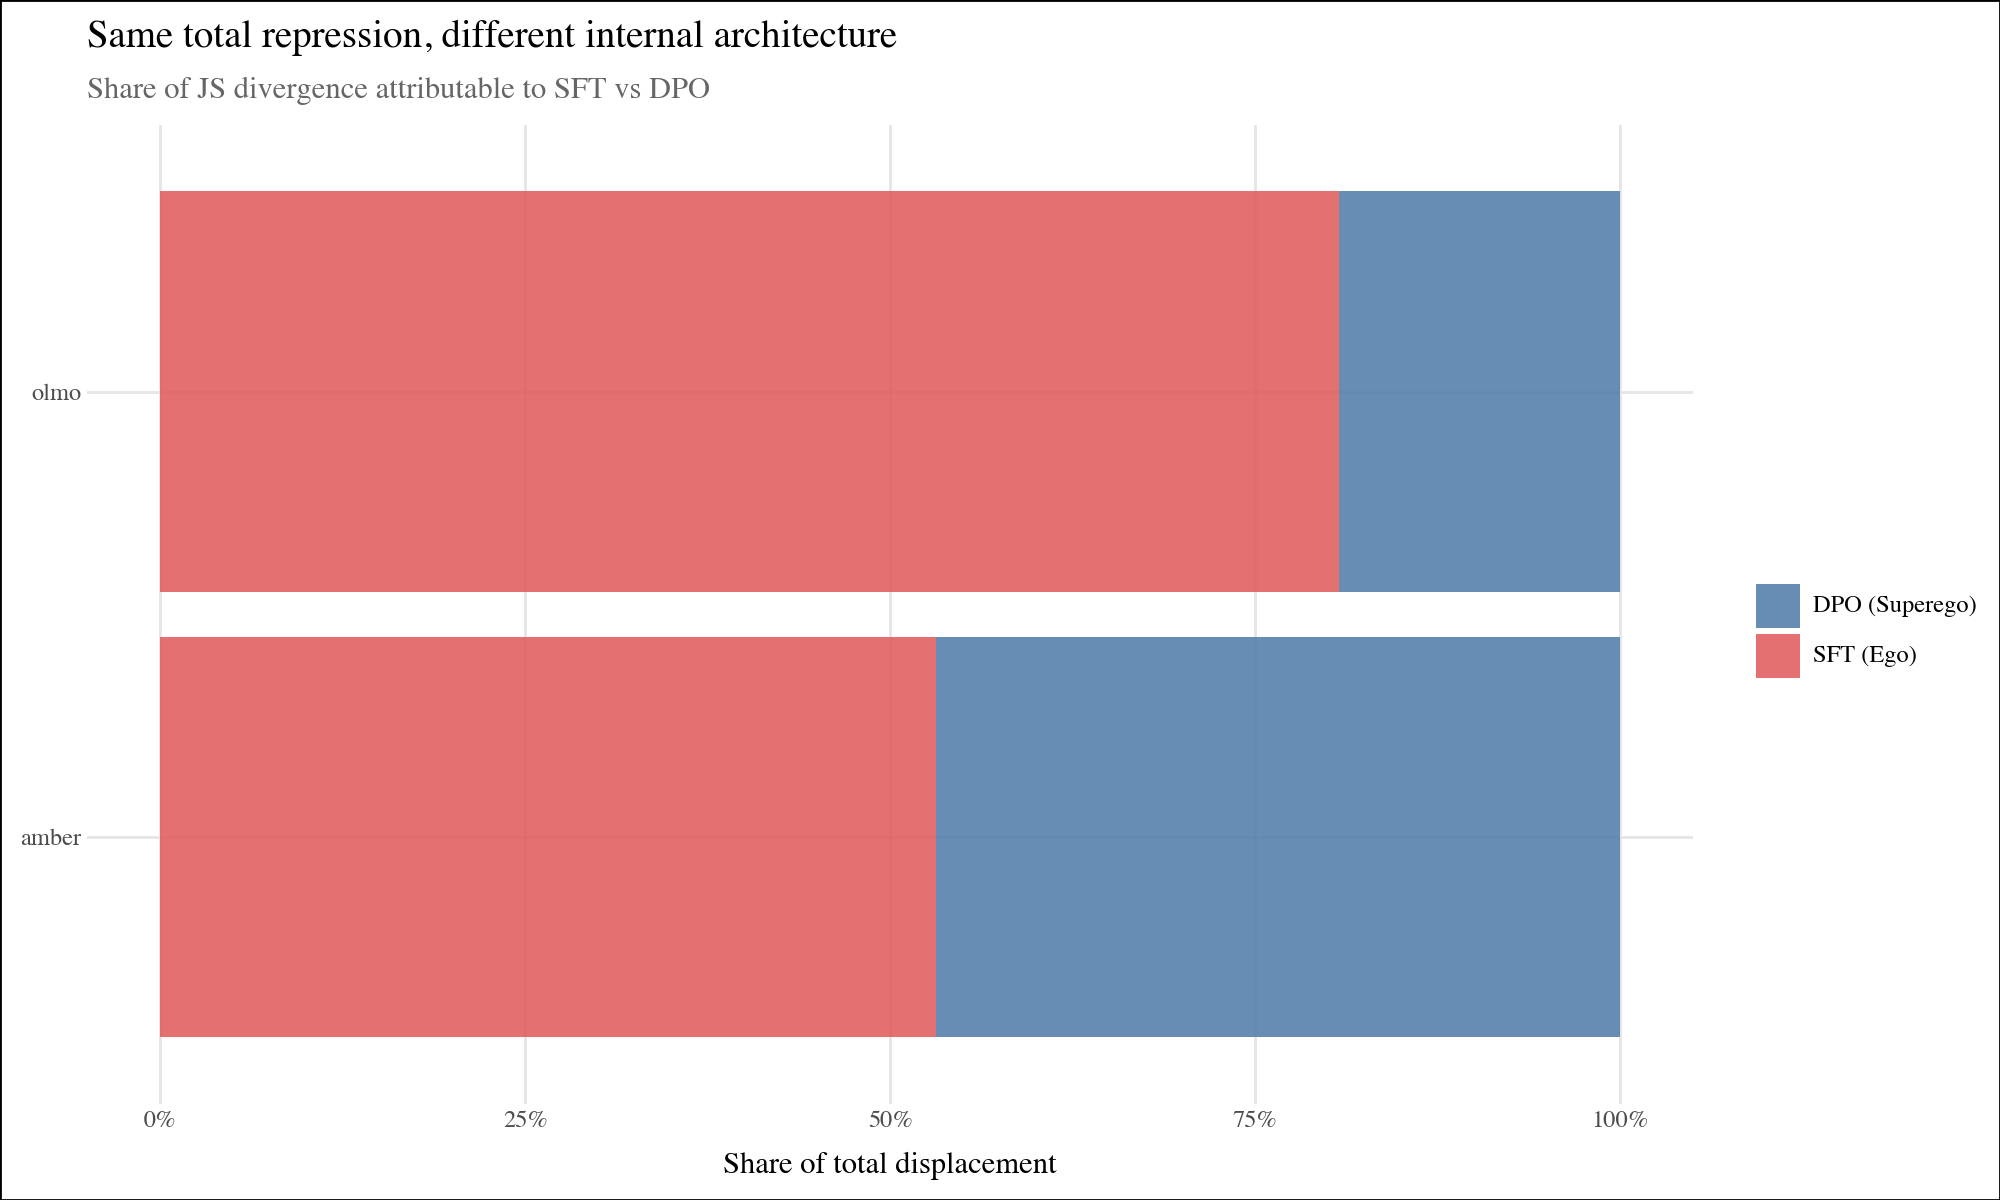

In [3]:
has_ego = df[df['js_base_ego'].notna() & (df['js_base_ego'] > 0)].copy()
has_ego['sft_share'] = has_ego['js_base_ego'] / has_ego['js_base_superego']
has_ego['dpo_share'] = 1 - has_ego['sft_share']

shares = has_ego.groupby('family')[['sft_share']].mean().reset_index()
shares['dpo_share'] = 1 - shares['sft_share']
shares_long = shares.melt(id_vars='family', var_name='stage', value_name='share')
shares_long['stage'] = shares_long['stage'].map({'sft_share': 'SFT (Ego)', 'dpo_share': 'DPO (Superego)'})

p = (ggplot(shares_long, aes(x='family', y='share', fill='stage'))
 + geom_col(position='stack', alpha=0.85)
 + scale_fill_manual(values=['#4e79a7', '#e15759'])
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + labs(title='Same total repression, different internal architecture',
        subtitle='Share of JS divergence attributable to SFT vs DPO',
        x='', y='Share of total displacement', fill='')
 + theme_malign
 + coord_flip()
)
p.save(FIGDIR / '02_sft_dpo_division.png', dpi=200)
p

## JS divergence by family and category

/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/02_category_heatmap.png


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.


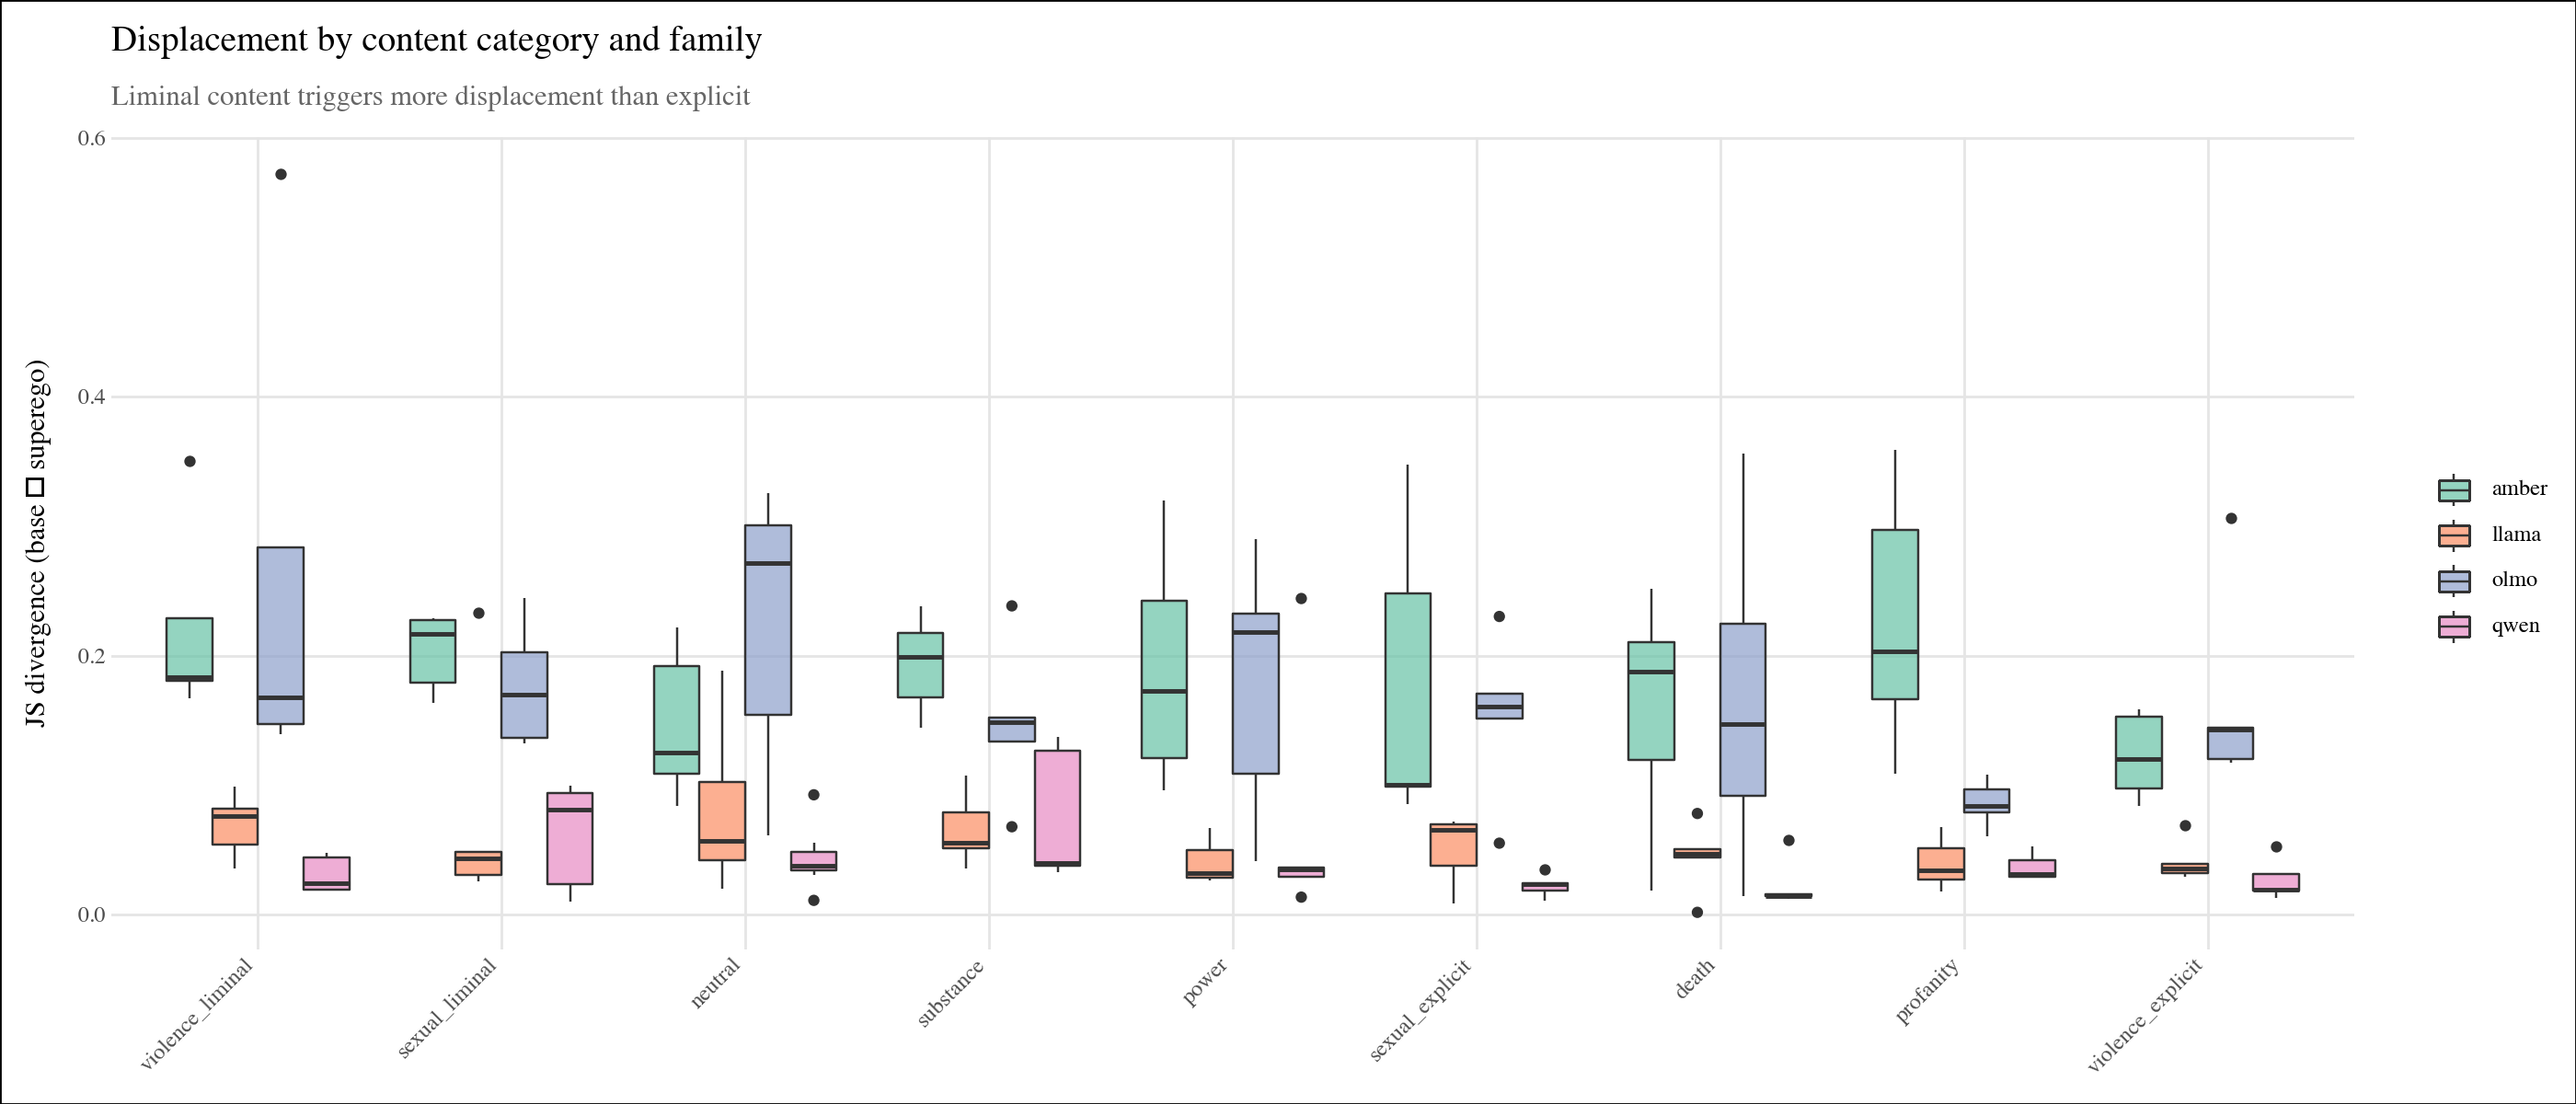

In [4]:
cat_order = df.groupby('category')['js_base_superego'].mean().sort_values(ascending=False).index.tolist()

p = (ggplot(df, aes(x='category', y='js_base_superego', fill='family'))
 + geom_boxplot(alpha=0.7, position='dodge')
 + scale_x_discrete(limits=cat_order)
 + scale_fill_brewer(type='qual', palette='Set2')
 + labs(title='Displacement by content category and family',
        subtitle='Liminal content triggers more displacement than explicit',
        x='', y='JS divergence (base → superego)', fill='')
 + theme_malign
 + theme(axis_text_x=element_text(rotation=45, ha='right'), figure_size=(14, 6))
)
p.save(FIGDIR / '02_category_heatmap.png', dpi=200)
p